# Gold prices with Machine Learning Predictions
## 1. Introduction
This project explores the application of machine learning techniques to predict gold prices. Gold, as a valuable commodity and safe-haven asset, is subject to numerous factors influencing its price movements. Understanding and predicting these movements can be highly beneficial for traders.
## 2. Background
Predicting financial markets, especially gold, is a complex task due to their non-linear, non-stationary, and noisy nature. Traditional statistical methods often struggle to capture these complexities.

Some machine learning models offer powerful tools to identify patterns and make predictions from historical data. This project uses these techniques, along with technical indicators commonly used in financial analysis, to build a predictive system for gold prices.

## 3. Loading data
To begin, I first need to gather information about gold prices and other assets by using a special tool called `yfinance`. `yfinance` can fetch financial information from the internet, much like you might check stock prices on a website.

As gold is a global macro-asset driven by geopolitical fear, inflation, and currency strength. Gold has specific correlations with other assets:
* **US Dollar Index**: Gold is priced in dollars. Historically, when the dollar gets strong, gold gets weak, and vice versa.
* **10-Year Treasury Yields**: Gold pays no dividends or interest. When interest rates (yields) go up, investors often sell gold to buy bonds. Including yield data is essential.
* **Oil Prices**: Gold is often treated as a commodity. It frequently moves in sympathy with broad commodity markets like Oil.
* **S&P 500**: Serves as a primary barometer of market sentiment. It helps predictive models gauge "Risk-On" vs. "Risk-Off" sentiment. "Risk-Off" signal is when the S&P 500 falls sharply, it indicates economic uncertainty. Investors tend to sell "risky" stocks and purchase gold as a safe-haven asset, driving up its price.

In [1]:
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta

# 1. Define the tickers
# GC=F: Gold
# ^GSPC: S&P 500
# CL=F: Crude Oil
# ^TNX: 10-Year Treasury Yield
# DX-Y.NYB: US Dollar Index
tickers = ['GC=F', '^GSPC', 'CL=F', '^TNX', 'DX-Y.NYB']

# 2. Download Data
# period="10y": Gets the last 10 years
# interval="1d": Uses Daily data
print("Downloading daily data in last 10 years...")
raw_data = yf.download(tickers, period = "10y", interval="1d")

# 3. Reformat Data
data = raw_data['Close'].copy()
data.columns = ['Oil', 'Dollar_Index', 'Gold', 'S&P500', 'Treasury_Yield']

# 4. Check the data range
print(f"\nData successfully downloaded.")
print(f"Start Date: {data.index.min()}")
print(f"End Date:   {data.index.max()}")
print(f"Total Rows: {data.shape[0]}")

data.tail()

/var/folders/2c/m_n_s4tn1yl_wl0vsn5dn3880000gn/T/ipykernel_29395/918967814.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, period = "10y", interval="1d")
[*********************100%***********************]  5 of 5 completed


Data successfully downloaded.
Start Date: 2016-02-10 00:00:00
End Date:   2026-02-11 00:00:00
Total Rows: 2519


,Oil,Dollar_Index,Gold,S&P500,Treasury_Yield
Date,,,,,
2026-02-05,63.290001,97.820000,4861.399902,6798.399902,4.210
2026-02-06,63.549999,97.629997,4951.200195,6932.299805,4.206
2026-02-09,64.360001,96.820000,5050.899902,6964.819824,4.198
2026-02-10,63.959999,96.800003,5003.799805,6941.810059,4.147
2026-02-11,64.599998,96.624001,5084.000000,NaN,NaN


## 4. Data Exploration
Before we feed data into a machine learning model, we need to explore to understand the gold price data.
### 4.1. Price History Chart
* **10-Year View**: This shows us the long-term cycles. It helps us see if the overall trend is rising or falling.
* **1-Year View**: This focuses on the recent "mood" of the market. Machine learning models pay more attention to recent data, so seeing if we are currently in a steep uptrend or a flat period helps us set expectations for the prediction.

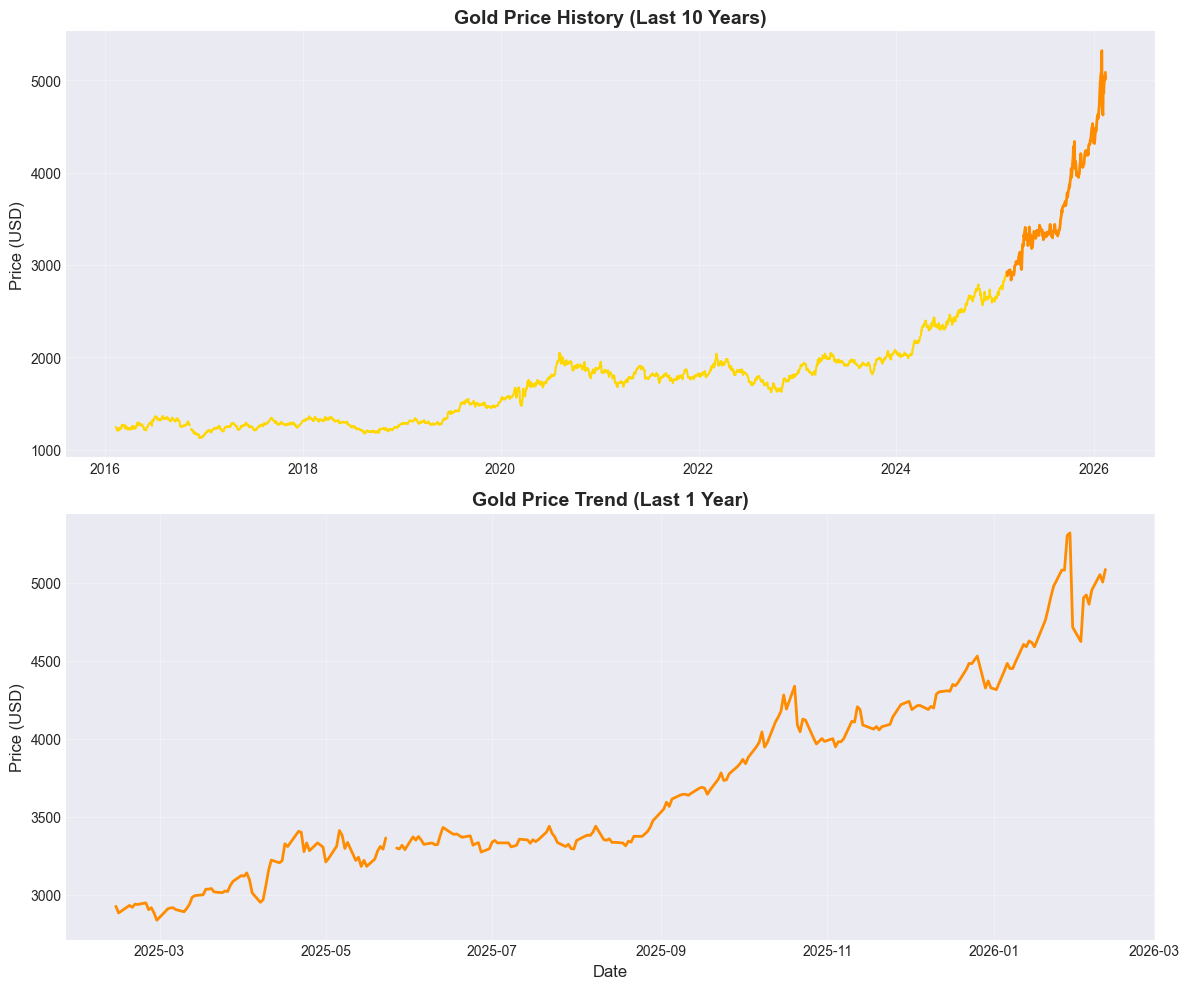

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
# Plot 1: Last 10 Years
ax1.plot(data.index, data['Gold'], color='gold', linewidth=1.5)
ax1.set_title('Gold Price History (Last 10 Years)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Last 1 Year
# Get the last 252 trading days (approx 1 year)
last_year_data = data.iloc[-252:]

ax1.plot(last_year_data.index, last_year_data['Gold'], color='darkorange', linewidth=2)

ax2.plot(last_year_data.index, last_year_data['Gold'], color='darkorange', linewidth=2)
ax2.set_title('Gold Price Trend (Last 1 Year)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Price (USD)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2. The Correlation Matrix (Heatmap)
This tells us how Gold relates to other markets.

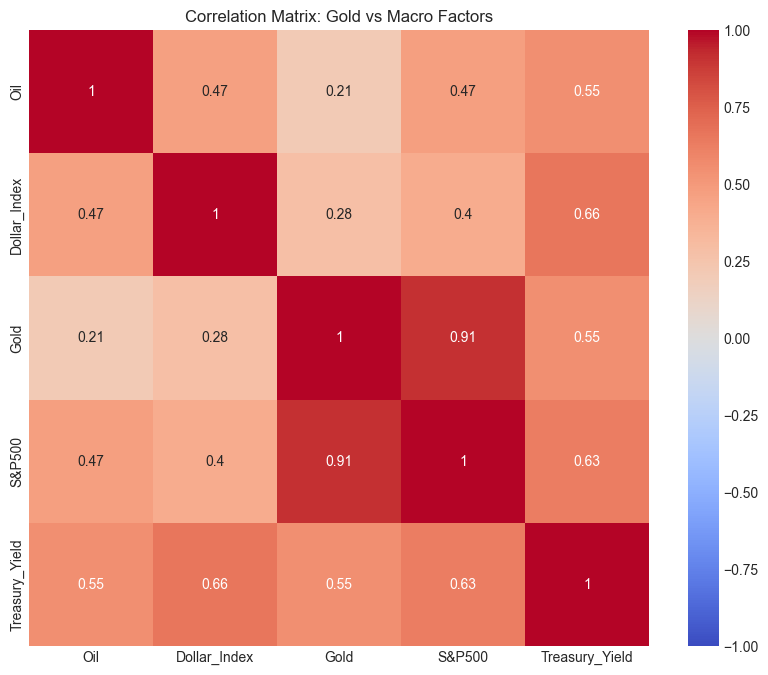

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Correlation Matrix: Gold vs Macro Factors")
plt.show()

**Problem**: All correlations are positive as we compute correlation on **price levels** (many assets trend over time, hence correlations get inflated). This is the statistical trap called "Spurious Correlation".

**Fix**: Compute correlations on returns (log returns / % change)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


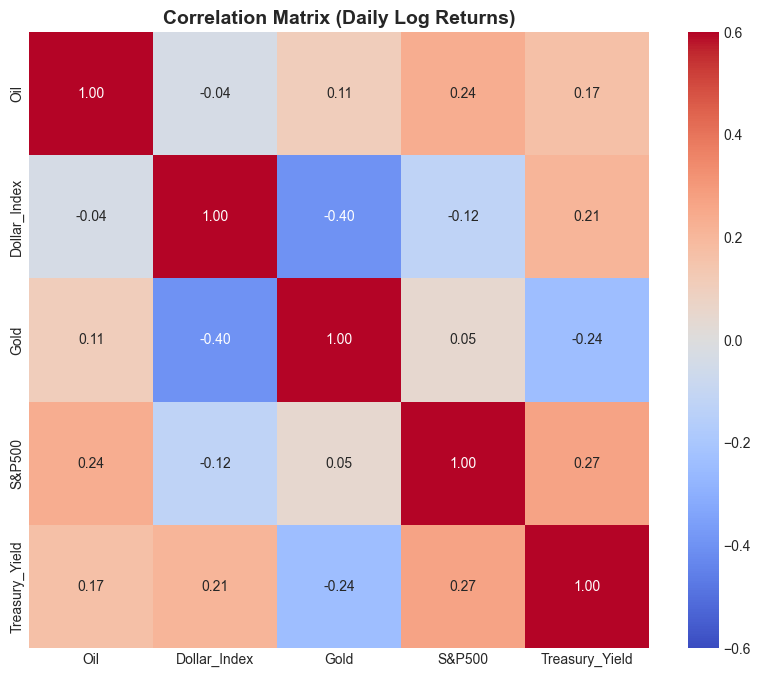

In [4]:
import numpy as np

# 1. Calculate Log Returns
log_returns = np.log(data / data.shift(1))

# Drop the first row (which becomes NaN after shifting)
log_returns.dropna(inplace=True)

# 2. Re-plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(log_returns.corr(), annot=True, cmap='coolwarm', fmt=".2f",
            vmin=-0.6, vmax=0.6, center=0)
# Note: I set vmin/vmax to -0.6/+0.6 because daily return correlations 
# are rarely perfect 1.0 or -1.0. This makes the colors more visible.

plt.title("Correlation Matrix (Daily Log Returns)", fontsize=14, fontweight='bold')
plt.show()

### 4.3. Data Preprocessing: Handling missing values
As gold market and bond market have different holidays which could lead to missing values. So, we need to fill the missing values by using **"Forward Fill"**. If we don't have a price for today, we assume it hasn't changed since yesterday. This is a standard and safe assumption for daily trading data.

In [5]:
print("Missing values before cleaning:")
print(data.isnull().sum())

# Forward Fill
# 'ffill' takes the value from the previous day and copies it forward
data.ffill(inplace=True)

# Drop remaining missing value
data.dropna(inplace=True)

print("\nMissing values after cleaning:")
print(data.isnull().sum())

Missing values before cleaning:
Oil               4
Dollar_Index      4
Gold              5
S&P500            5
Treasury_Yield    5
dtype: int64

Missing values after cleaning:
Oil               0
Dollar_Index      0
Gold              0
S&P500            0
Treasury_Yield    0
dtype: int64


## 5. Data processing
### 5.1. Feature Engineering
#### Momentum Indicators: RSI & MACD
* These tell you how fast the price is changing.
* If the price goes too fast, it is likely to fall back down. So, these indicators help the model spot when a trend is about to reverse.
#### Volatility: Bollinger Width, Rolling Volatility
* These measure how calm/stormy the market is.
* Gold price act differently when the market is panicked or quiet. So, these features can warn the model if a wild price swing is likely to happen.
#### Market Memory: Lags & Log returns
* **Log Returns**: The daily percentage change.
* **Lags**: We explicitly give the model the price from 1, 2, and 3 days ago. This allows the model to "remember" the recent trend pattern.

#### Macroeconomic features
To improve model's accuracy, we need Inter-market Analysis. Gold price also moves based on:
* **The US Dollar (DXY)**: When Dollar goes UP, Gold usually goes DOWN.
* **Treasury Yields (TNX)**: When Rates go UP, Gold (which pays no interest) usually goes DOWN.

**NOTE**: We must normilize **absolute values** into **relative values** (Percentages/Ratios).

In [6]:
# 1. MOMENTUM INDICATORS

# Feature 1: RSI (Relative Strength Index)
# Measures if Gold is "Overbought" (>70) or "Oversold" (<30)
# CONCEPT: We need to compare the average "Up" moves vs. the average "Down" moves

delta = data['Gold'].diff()

gain = (delta.where(delta > 0, 0))
loss = (-delta.where(delta < 0, 0))

avg_gain = gain.ewm(com=13, adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()

rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

# Feature 2: MACD (Moving Average Convergence Divergence)
# A trend-following momentum indicator
# CONCEPT: The difference between a "Fast" average (12 days) and "Slow" average (26 days)

ema12 = data['Gold'].ewm(span=12, adjust=False).mean()
ema26 = data['Gold'].ewm(span=26, adjust=False).mean()

# Divide by price to get percentage
data['MACD_Pct'] = (ema12 - ema26) / data['Gold'] 
data['MACD_Signal_Pct'] = data['MACD_Pct'].ewm(span=9, adjust=False).mean()

data.tail()

,Oil,Dollar_Index,Gold,S&P500,Treasury_Yield,RSI,MACD_Pct,MACD_Signal_Pct
Date,,,,,,,,
2026-02-05,63.290001,97.820000,4861.399902,6798.399902,4.210,54.415159,0.026036,0.030834
2026-02-06,63.549999,97.629997,4951.200195,6932.299805,4.206,57.273293,0.024842,0.029635
2026-02-09,64.360001,96.820000,5050.899902,6964.819824,4.198,60.252960,0.025095,0.028727
2026-02-10,63.959999,96.800003,5003.799805,6941.810059,4.147,58.188446,0.024879,0.027958
2026-02-11,64.599998,96.624001,5084.000000,6941.810059,4.147,60.660225,0.025118,0.027390


In [7]:
from scipy.stats import linregress

def get_slope(array):
    y = np.array(array)
    x = np.arange(len(y))
    if np.isnan(y).any(): return 0
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    return slope

# 2. TREND INDICATORS

# SMA 12 - Short-term (2 weeks)
data['SMA_12'] = data['Gold'].rolling(window=12).mean()
# SMA 60 - Intermediate Trend (3 months)
data['SMA_60'] = data['Gold'].rolling(window=60).mean()
# SMA 150 - Long-term Trend (7.5 months)
data['SMA_150'] = data['Gold'].rolling(window=150).mean()

# Feature 3, 4, 5: Slopes of Moving Averages
# Is the trend pointing UP or DOWN?
slope_window = 7 
data['Slope_SMA12'] = data['SMA_12'].rolling(window=slope_window).apply(get_slope, raw=True)
data['Slope_SMA60'] = data['SMA_60'].rolling(window=slope_window).apply(get_slope, raw=True)
data['Slope_SMA150'] = data['SMA_150'].rolling(window=slope_window).apply(get_slope, raw=True)

# Feature 6, 7, 8: Distance from SMA
# This tells you: "Is Gold expensive right now?"
data['Dist_from_SMA12'] = (data['Gold'] - data['SMA_12']) / data['SMA_12']
data['Dist_from_SMA60'] = (data['Gold'] - data['SMA_60']) / data['SMA_60']
data['Dist_from_SMA150'] = (data['Gold'] - data['SMA_150']) / data['SMA_150']

# Feature 9: Bollinger Width (Volatility)
std_20 = data['Gold'].rolling(window=20).std()
bb_upper = data['SMA_12'] + (2 * std_20)
bb_lower = data['SMA_12'] - (2 * std_20)
data['BB_Width'] = (bb_upper - bb_lower) / data['SMA_12']

data.tail()

,Oil,Dollar_Index,Gold,S&P500,Treasury_Yield,RSI,MACD_Pct,MACD_Signal_Pct,SMA_12,SMA_60,SMA_150,Slope_SMA12,Slope_SMA60,Slope_SMA150,Dist_from_SMA12,Dist_from_SMA60,Dist_from_SMA150,BB_Width
Date,,,,,,,,,,,,,,,,,,
2026-02-05,63.290001,97.820000,4861.399902,6798.399902,4.210,54.415159,0.026036,0.030834,4959.858317,4440.351652,3962.336655,19.145243,14.556131,10.232786,-0.019851,0.094823,0.226902,0.202466
2026-02-06,63.549999,97.629997,4951.200195,6932.299805,4.206,57.273293,0.024842,0.029635,4969.808350,4454.341659,3973.127990,14.698520,14.003811,10.072048,-0.003744,0.111545,0.246172,0.191261
2026-02-09,64.360001,96.820000,5050.899902,6964.819824,4.198,60.252960,0.025095,0.028727,4981.650024,4470.076660,3984.585990,15.034832,14.574823,10.400500,0.013901,0.129936,0.267610,0.182593
2026-02-10,63.959999,96.800003,5003.799805,6941.810059,4.147,58.188446,0.024879,0.027958,4983.949992,4483.399992,3995.897988,13.817564,14.761787,10.747119,0.003983,0.116073,0.252234,0.177149
2026-02-11,64.599998,96.624001,5084.000000,6941.810059,4.147,60.660225,0.025118,0.027390,4984.308309,4498.351660,4007.713988,9.597915,14.595716,10.998047,0.020001,0.130192,0.268554,0.171266


In [8]:
# 3. CORRELATIONS & INTERMARKET

# Log Returns of ALL assets
# As prices get inflated over time, percentage changes are more consistent. 
data['Log_Returns'] = np.log(data['Gold'] / data['Gold'].shift(1))

data['Log_Ret_Oil']  = np.log(data['Oil'] / data['Oil'].shift(1))
data['Log_Ret_DXY']  = np.log(data['Dollar_Index'] / data['Dollar_Index'].shift(1))
data['Log_Ret_SPX']  = np.log(data['S&P500'] / data['S&P500'].shift(1))

# Feature 10, 11: Rolling 20-day Correlations: Are they fighting or moving together?
data['Corr_Gold_DXY'] = data['Log_Returns'].rolling(20).corr(data['Log_Ret_DXY'])
data['Corr_Gold_Oil'] = data['Log_Returns'].rolling(20).corr(data['Log_Ret_Oil'])

# Feature 12: Dollar strength
data['DXY_Rel_Strength'] = (data['Dollar_Index'] - data['Dollar_Index'].rolling(50).mean()) / data['Dollar_Index']

# Feature 13: Yield Change
# Yields going from 1.0 to 1.1 is different than 4.0 to 4.1
data['TNX_Pct_Change'] = data['Treasury_Yield'].pct_change(5)

# Feature 14: Gold/SPX Ratio: If this goes UP, investors are fleeing stocks for safety.
# The raw ratio changes over decades. Use "Distance from its own mean"
ratio = data['Gold'] / data['S&P500']
data['Gold_SPX_Ratio_Dist'] = (ratio - ratio.rolling(50).mean()) / ratio

# Clean up
data.dropna(inplace=True)

print("✅ Feature Engineering Complete")
data.head()

✅ Feature Engineering Complete


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Oil,Dollar_Index,Gold,S&P500,Treasury_Yield,RSI,MACD_Pct,MACD_Signal_Pct,SMA_12,SMA_60,...,BB_Width,Log_Returns,Log_Ret_Oil,Log_Ret_DXY,Log_Ret_SPX,Corr_Gold_DXY,Corr_Gold_Oil,DXY_Rel_Strength,TNX_Pct_Change,Gold_SPX_Ratio_Dist
Date,,,,,,,,,,,,,,,,,,,,,
2016-09-22,46.320000,95.449997,1340.400024,2177.179932,1.632,57.129175,-0.001630,-0.002446,1323.875010,1333.828339,...,0.036727,0.010123,0.021384,-0.002198,0.006479,-0.637804,0.288262,-0.003156,-0.041691,0.002772
2016-09-23,44.480000,95.480003,1337.199951,2164.689941,1.615,55.379508,-0.000707,-0.002099,1323.283335,1334.050004,...,0.037967,-0.002390,-0.040534,0.000314,-0.005753,-0.643201,0.320559,-0.002715,-0.050558,0.006041
2016-09-26,45.930000,95.309998,1339.699951,2146.100098,1.589,56.500359,0.000176,-0.001644,1323.524994,1334.405003,...,0.039457,0.001868,0.032079,-0.001782,-0.008625,-0.711894,0.317938,-0.004237,-0.063090,0.016075
2016-09-27,44.669998,95.440002,1325.900024,2159.929932,1.556,49.159565,0.000044,-0.001306,1323.174998,1334.225004,...,0.039464,-0.010354,-0.027816,0.001363,0.006423,-0.698177,0.364294,-0.002634,-0.078199,-0.000599
2016-09-28,47.049999,95.430000,1319.400024,2171.370117,1.567,46.120059,-0.000455,-0.001136,1323.041667,1333.608337,...,0.038592,-0.004914,0.051909,-0.000105,0.005283,-0.667414,0.257904,-0.002400,-0.060552,-0.010600


### 5.2. Splitting the Data
As **sampling must not be random** in time series data, we split the data in chronological order. We train on the Past (e.g., 2015–2022) and test on the Future (e.g., 2023–2024).
1. **Training Set**: Learns patterns from this data (First 80% of history).
2. **Test Set**: Used it to test how well it predicts the future (Last 20% of history).

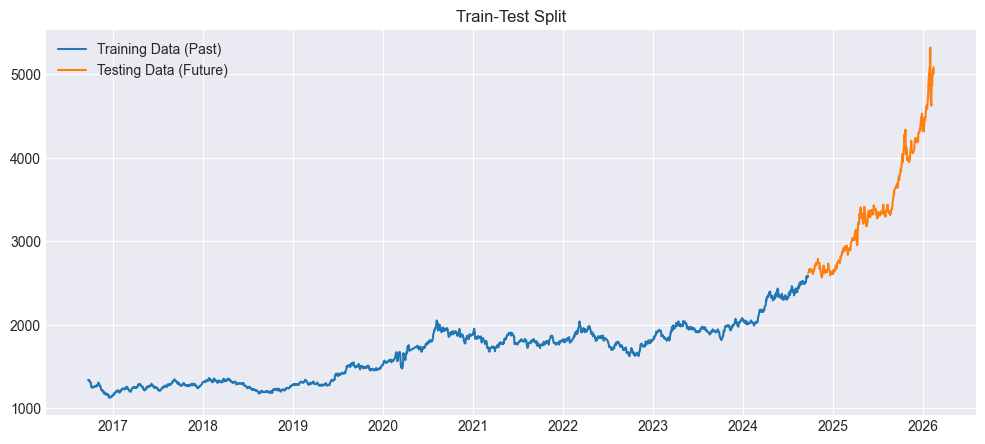

In [9]:
# Re-order columns
drop_cols = [
    'Gold', 'Oil', 'Dollar_Index', 'S&P500', 'Treasury_Yield', 
    'SMA_12', 'SMA_60', 'SMA_150', 
    'Log_Returns', 'Log_Ret_Oil', 'Log_Ret_DXY', 'Log_Ret_SPX',
    'Target_1D', 'Target_1W'
]

# 1. Separate Features (X) and Target (y)
X = data.drop(columns=drop_cols, errors='ignore')
Y = data['Gold']

# 2. Split the data chronologically
# Define the Split Point (e.g., 85% Train, 15% Test)
split_index = int(len(data) * 0.85)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

Y_train = Y.iloc[:split_index]
Y_test = Y.iloc[split_index:]

# Visualize the split
plt.figure(figsize=(12, 5))
plt.plot(Y_train.index, Y_train, label='Training Data (Past)')
plt.plot(Y_test.index, Y_test, label='Testing Data (Future)')
plt.title("Train-Test Split")
plt.legend()
plt.show()

### 5.3. Fix the problem: Non-stationarity in Time series data
After, viewing the chart, I found a problem: The test period lives in a very different “world” (rapid acceleration) than most of the training period, so a model trained on price levels struggles. Tree-based models cannot draw a line that points up to infinity. They work by memorizing the data they have seen.

Hence, instead of predicting "What will the price be?", we should predict "By what percentage will the price change?" (e.g., +0.5%).

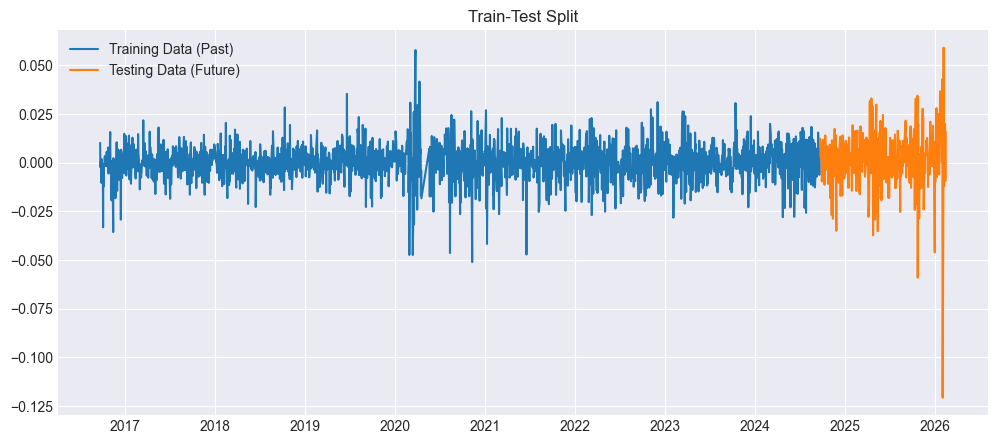

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

drop_cols = [
    'Gold', 'Oil', 'Dollar_Index', 'S&P500', 'Treasury_Yield', 
    'SMA_12', 'SMA_60', 'SMA_150', 
    'Log_Returns', 'Log_Ret_Oil', 'Log_Ret_DXY', 'Log_Ret_SPX',
    'Target_1D', 'Target_1W'
]

Y = data['Log_Returns']
X = data.drop(columns=drop_cols, errors='ignore')

split = int(len(data) * 0.85)
X_train, X_test = X.iloc[:split], X.iloc[split:]
Y_train, Y_test = Y.iloc[:split], Y.iloc[split:]

# Store actual gold prices for reconstruction
gold_prices_train = data['Gold'].iloc[:split]
gold_prices_test = data['Gold'].iloc[split:]

# Visualize the split
plt.figure(figsize=(12, 5))
plt.plot(Y_train.index, Y_train, label='Training Data (Past)')
plt.plot(Y_test.index, Y_test, label='Testing Data (Future)')
plt.title("Train-Test Split")
plt.legend()
plt.show()

## 6. Model training
To predict the future gold price, I consider using "tree-based" algorithms instead of simple algorithms like Linear Regression. Here is why:
* It can handle "Non-Linear" relationships, as gold prices don't move in a straight line. Sometimes Gold ignores the Dollar, and sometimes it reacts violently. Linear Regression fails here, but "tree-based" models can learn these complex "if-this-then-that" rules.
* It is harder to be overfitting. When using models with many trees, it cancels out individual errors.
* These models can tell you which feature was most important. This is important to understand which factors influence the movement of gold price.

#### 1. Random Forest
* A machine learning algorithm that uses many decision trees, each one looks at different random parts of the data and their results are combined by voting. Imagine you are asking 100 financial analysts for their prediction as each one looks at a random subset, then takes the average of all these 100 guesses to form the final prediction.
#### 2. XGBoost (eXtreme Gradient Boosting)
* Instead of building 100 trees at the same time like Random Forest, XGBoost builds them one by one. The first tree makes a guess, the second one looks at the first tree's mistake to improve. The process repeats, making the model smarter.

### 6.1. Train Random Forest

In [11]:
from sklearn.ensemble import RandomForestRegressor

print("\n🌲 Training Random Forest Model...")

rf_model = RandomForestRegressor(
    # More trees = smoother predictions and less variance, but slower to train
    n_estimators = 200,
    
    # Limits how "tall" each tree can grow. Avoid overfitting
    max_depth = 10,
    
    # A node needs at least 20 data points to split further
    min_samples_split = 20,
    
    # Every end-point (leaf) must have at least 10 data points (days)
    min_samples_leaf = 10,
    
    # Each tree only looks at the square root of total features (e.g. 25 features, it looks at 5)
    # This forces trees to be different from each other
    max_features = 'sqrt',
    
    # Ensure the result is the same
    random_state = 42
)

rf_model.fit(X_train, Y_train)
rf_pred_returns = rf_model.predict(X_test)

print("✅ Random Forest training complete!")


🌲 Training Random Forest Model...
✅ Random Forest training complete!


### 6.2. Train XGBoost

In [12]:
from xgboost import XGBRegressor

print("\n🚀 Training XGBoost Model...")

xgb_model = XGBRegressor(
    # Number of trees
    n_estimators=200,
    
    # Learning rate - the "step size"
    learning_rate = 0.05,
    
    # XGBoost trees are usually shallower than Random Forest trees
    # Depth 6 is a standard starting point for tabular data
    max_depth = 6,
    min_child_weight = 3,

    # For every tree, use only 80% of the training rows
    # This adds randomness and prevents overfitting
    subsample = 0.8,

    # Use only 80% of the columns (features) for each tree
    # Similar to max_features='sqrt' in Random Forest
    colsample_bytree = 0.8,

    # Minimum loss reduction required to make a split.
    # If a split doesn't improve the model significantly, XGBoost won't do it.
    gamma = 0.1,
    random_state = 42
)

xgb_model.fit(X_train, Y_train)
xgb_pred_returns = xgb_model.predict(X_test)

print("✅ XGBoost training complete!")


🚀 Training XGBoost Model...
✅ XGBoost training complete!


### 6.3. Reconstruct prices from log returns
As we predicted "What percentage will the price change?", we take these results to predict back the future gold price.
* **Formula**: `Price (at day t)` = `Actual Price (at day t-1)` * `Predicted Result`
* E.g. In real trading, you wake up, see the REAL price from yesterday, and apply your prediction only to today.

In [13]:
print("\n💰 Reconstructing prices from predicted returns...")

# Get the last training price as anchor
last_train_price = gold_prices_train.iloc[-1]

def reconstruct_prices(predicted_returns, actual_prices):
    
    predicted_prices = []
    
    for i in range(len(predicted_returns)):
        if i == 0:
            # Use last training price for first prediction
            prev_price = last_train_price
        else:
            # Use actual previous price
            prev_price = actual_prices.iloc[i-1]
        
        # Reconstruct: Price_t = Price_{t-1} * exp(log_return_t)
        predicted_price = prev_price * np.exp(predicted_returns[i])
        predicted_prices.append(predicted_price)
    
    return pd.Series(predicted_prices, index=actual_prices.index)

# Reconstruct prices for both models
rf_predicted_prices = reconstruct_prices(rf_pred_returns, gold_prices_test)
xgb_predicted_prices = reconstruct_prices(xgb_pred_returns, gold_prices_test)

print("✅ Price reconstruction complete!")


💰 Reconstructing prices from predicted returns...
✅ Price reconstruction complete!


### 6.4. Model Evaluation - Data Visualization
The full chart looks perfect because we used yesterday's price to reset the prediction. By zooming in on the last 100 days, we can see if the model is truly predicting the turns or just reacting late.

📈 Visualizing the result...


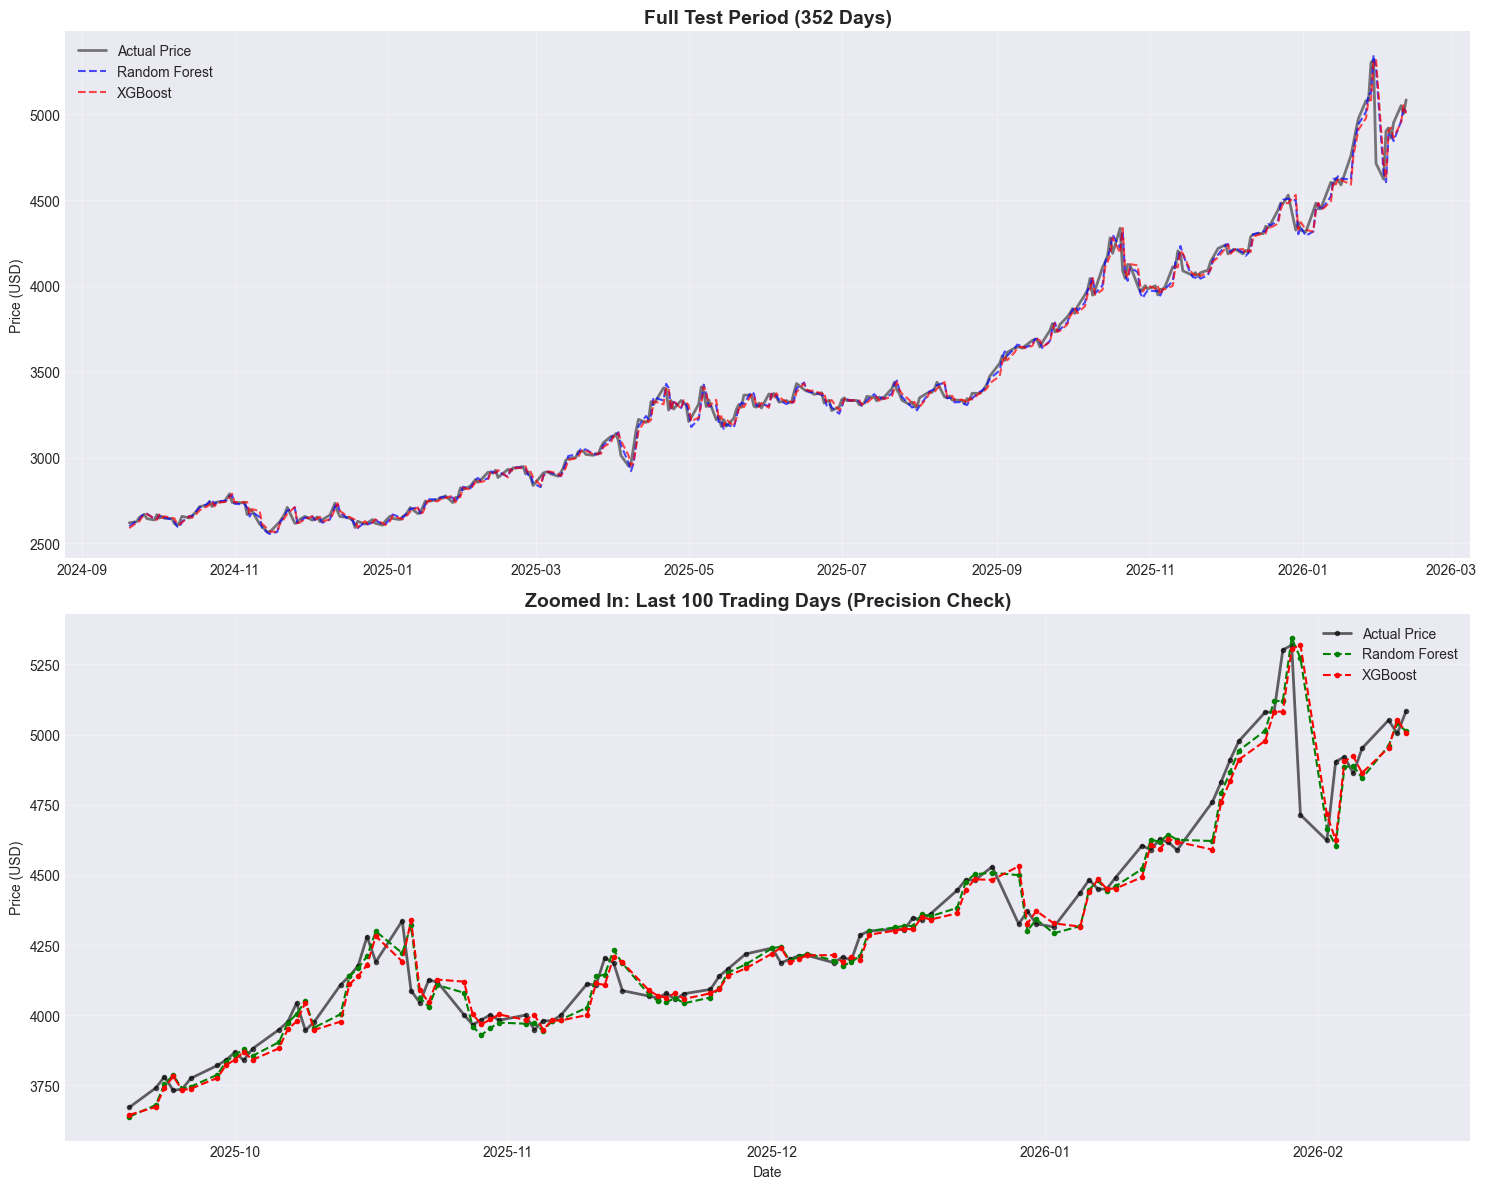

In [14]:
print("📈 Visualizing the result...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: The Full Test Set
ax1.plot(gold_prices_test.index, gold_prices_test, label='Actual Price', color='black', alpha=0.5, linewidth=2)
ax1.plot(rf_predicted_prices.index, rf_predicted_prices, label='Random Forest', color='blue', linestyle='--', alpha=0.7)
ax1.plot(xgb_predicted_prices.index, xgb_predicted_prices, label='XGBoost', color='red', linestyle='--', alpha=0.7)

ax1.set_title(f"Full Test Period ({len(gold_prices_test)} Days)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Price (USD)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# PLOT 2: The "Micro" View
zoom_days = 100
ax2.plot(gold_prices_test.index[-zoom_days:], gold_prices_test[-zoom_days:], label='Actual Price', color='black', alpha=0.6, linewidth=2, marker='.')
ax2.plot(rf_predicted_prices.index[-zoom_days:], rf_predicted_prices[-zoom_days:], label='Random Forest', color='green', linestyle='--', marker='.')
ax2.plot(xgb_predicted_prices.index[-zoom_days:], xgb_predicted_prices[-zoom_days:], label='XGBoost', color='red', linestyle='--', marker='.')

ax2.set_title(f"Zoomed In: Last {zoom_days} Trading Days (Precision Check)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Price (USD)")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. One-day predictive models (Change to Classification models)
In finance, predicting the exact price is impossible. Hence, we care more about the **Direction (up and down)**. Hence, we are going to build One-Day and One-Week predictive models. We will move away from predicting the raw Price (which is non-stationary and hard to predict) to predicting the Market Direction (Up/Down), which is the industry standard for precision.

### 7.1. Define binary target

In [15]:
# -- 1. Define binary target --
# One day prediction target
# If Price(t+1) > Price(t), Target = 1 (Up), else 0 (Down)
data['Target_1D'] = (data['Gold'].shift(-1) > data['Gold']).astype(int)

# Drop null row created by lagging/rolling
data_clean = data.dropna()

print("One-day prediction target has", np.sum(Y == 1), "Up,", np.sum(Y == 0), "Down")

One-day prediction target has 0 Up, 13 Down


### 7.2. Advanced Data Splitting & Weighting (Financial Time Series)

In financial machine learning, standard random splitting doesn't work because market data is sequential.
1.  **Chronological Split with Gap:** Prevents "Data Leakage" where future information (like lags) bleeds into the past.
2.  **Validation Set:** A separate set to tune parameters without touching the final Test data.
3.  **Sample Weights (Time Decay):** Forces the model to prioritize recent 2024-2026 data over old 2016 data.

In [16]:
# 1. Feature Clean Up
drop_cols = [
    'Gold', 'Oil', 'Dollar_Index', 'S&P500', 'Treasury_Yield', 
    'SMA_12', 'SMA_60', 'SMA_150', 
    'Log_Returns', 'Log_Ret_Oil', 'Log_Ret_DXY', 'Log_Ret_SPX',
    'Target_1D', 'Target_1W'
]
X = data_clean.drop(columns = drop_cols, errors='ignore') 
Y = data_clean['Target_1D']

# Ensure remaining features are numeric and relevant
print(f"Remaining Features ({len(X.columns)}): {list(X.columns)}")

# 2. Advanced Chronological Split with GAP
# We split: Train (70%) -> Valid (15%) -> Test (15%)
# Gap: Drop 2 days between sets to prevent lag leakage
train_end = int(len(X) * 0.70)
valid_end = int(len(X) * 0.85)
gap = 2

# Training Set
X_train = X.iloc[:train_end]
Y_train = Y.iloc[:train_end]

# Validation Set (Used to tune model, stop early, etc)
X_valid = X.iloc[train_end + gap : valid_end]
Y_valid = Y.iloc[train_end + gap : valid_end]

# Testing Set (Used only for final evaluation)
X_test = X.iloc[valid_end + gap:]
Y_test = Y.iloc[valid_end + gap:]

# 3. Time Decay
# We want the model to pay 5x more attention to 2024 data than 2016 data.
# -1.5 decay implies the oldest data has weight ~0.22, newest has 1.0
decay_rate = -1.5 
train_weights = np.exp(np.linspace(decay_rate, 0, len(X_train)))

# 4. Class Balance Calculation
train_up = np.sum(Y_train == 1)
train_down = np.sum(Y_train == 0)

# For XGBoost: If Up is majority, this number will be < 1, which reduces False Positives on Up.
scale_pos_weight = train_down / train_up

print(f"--- Data Configuration ---")
print(f"Train: {len(X_train)} days | Valid: {len(X_valid)} days | Test: {len(X_test)} days")
print(f"Gap size: {gap} days (removed to prevent leakage)")
print(f"Training Class Balance: {train_up} Up vs {train_down} Down")
print(f"Recommended scale_pos_weight: {scale_pos_weight:.3f}")
print(f"Sample Weights: Newest data is {1.0/np.exp(decay_rate):.1f}x more important than oldest.")

Remaining Features (15): ['RSI', 'MACD_Pct', 'MACD_Signal_Pct', 'Slope_SMA12', 'Slope_SMA60', 'Slope_SMA150', 'Dist_from_SMA12', 'Dist_from_SMA60', 'Dist_from_SMA150', 'BB_Width', 'Corr_Gold_DXY', 'Corr_Gold_Oil', 'DXY_Rel_Strength', 'TNX_Pct_Change', 'Gold_SPX_Ratio_Dist']
--- Data Configuration ---
Train: 1639 days | Valid: 349 days | Test: 350 days
Gap size: 2 days (removed to prevent leakage)
Training Class Balance: 872 Up vs 767 Down
Recommended scale_pos_weight: 0.880
Sample Weights: Newest data is 4.5x more important than oldest.


### 7.3. Train Models

In [17]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score

# -- Train Random Forest Classifier Model --
print("\n🌲 Training Random Forest Classifier...")


rf_day = RandomForestClassifier(
    n_estimators=500, 
    min_samples_split=20,
    max_depth=8,            # Slightly deeper since we have min_samples restriction
    class_weight='balanced', 
    n_jobs=-1,              # Use all CPU cores (faster)
    random_state=42
)

rf_day.fit(X_train, Y_train, sample_weight=train_weights)

# Get predictions
rf_day_pred = rf_day.predict(X_test)


# -- Train XGBoost Classifier Model --
print("\n🚀 Training XGBoost Classifier...")

xgb_day = XGBClassifier(
    n_estimators=1000,         # High number, but early_stopping will cut it short
    learning_rate=0.02,        # Slower learning = more robust
    max_depth=5,               # Shallower trees to prevent memorizing noise
    subsample=0.8,             # Use only 80% of data per tree (prevents overfitting)
    colsample_bytree=0.8,      # Use only 80% of features per tree
    reg_alpha=0.1,             # L1 Regularization (removes useless features)
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    early_stopping_rounds=50,
    random_state=42
)

xgb_day.fit(
    X_train, Y_train,
    sample_weight=train_weights,
    eval_set=[(X_train, Y_train), (X_valid, Y_valid)],
    verbose=False
)

print("✅ Training Complete")


🌲 Training Random Forest Classifier...

🚀 Training XGBoost Classifier...
✅ Training Complete


### 7.2. Model Evaluation
For classification model, we evaluate by confusion maxtrix with metrics like Presicion & Recall.
> * **Precision**: Focus on quality of the model’s predictions. It tells us how many of the "positive" predictions were actually correct.
> * **Recall**: Show how good the model is at predicting positives. It shows the % true positives detected out of all the actual positive instances.
> * Hence, in finance, I prioritize **Precision**, as I better to trade less but be right when I do. 


              --- 🌲 Random Forest Model Report ---
              precision    recall  f1-score   support

        Down       0.42      0.50      0.46       142
          Up       0.61      0.53      0.57       208

    accuracy                           0.52       350
   macro avg       0.52      0.52      0.51       350
weighted avg       0.53      0.52      0.52       350


              --- 🚀 XGBoost Model Report ---
              precision    recall  f1-score   support

        Down       0.41      0.63      0.50       142
          Up       0.60      0.38      0.47       208

    accuracy                           0.48       350
   macro avg       0.51      0.51      0.48       350
weighted avg       0.53      0.48      0.48       350



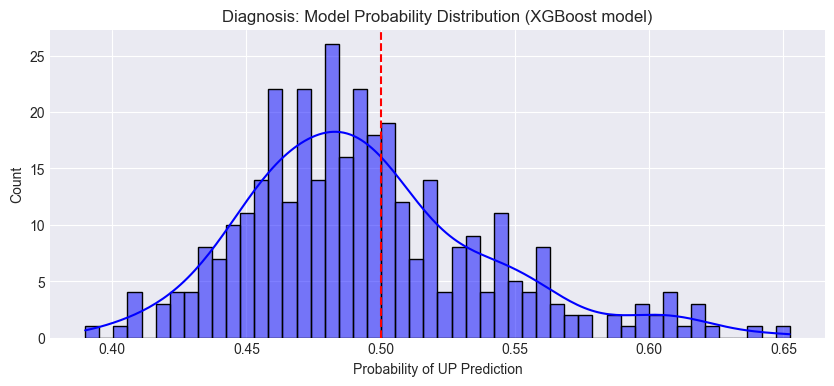

Min Probability: 0.3899
Max Probability: 0.6524
Mean Probability: 0.4946


In [18]:
from sklearn.metrics import confusion_matrix, classification_report

print("\n              --- 🌲 Random Forest Model Report ---")
print(classification_report(Y_test, rf_day_pred, target_names=['Down', 'Up']))

print("\n              --- 🚀 XGBoost Model Report ---")
print(classification_report(Y_test, xgb_day.predict(X_test), target_names=['Down', 'Up']))

# 1. Diagnose the Probabilities
probs = xgb_day.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 4))
sns.histplot(probs, bins=50, kde=True, color='blue')
plt.axvline(0.5, color='red', linestyle='--')
plt.title("Diagnosis: Model Probability Distribution (XGBoost model)")
plt.xlabel("Probability of UP Prediction")
plt.show()

print(f"Min Probability: {probs.min():.4f}")
print(f"Max Probability: {probs.max():.4f}")
print(f"Mean Probability: {probs.mean():.4f}")

### 7.3. Feature Importance

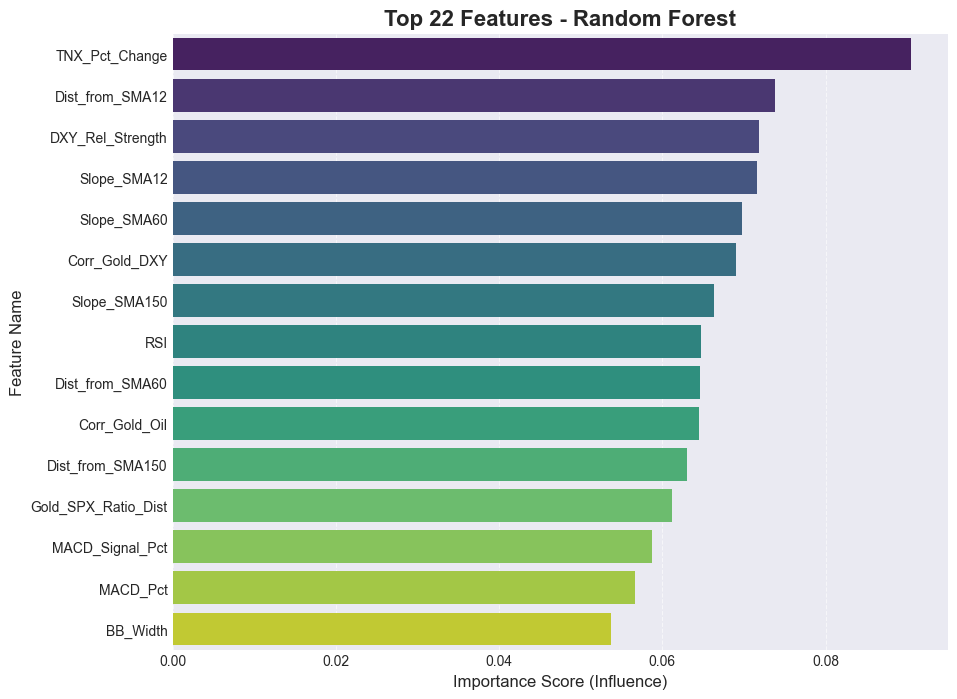


--- Top 10 Drivers for Random Forest ---
TNX_Pct_Change: 0.0904
Dist_from_SMA12: 0.0739
DXY_Rel_Strength: 0.0718
Slope_SMA12: 0.0716
Slope_SMA60: 0.0698
Corr_Gold_DXY: 0.0691
Slope_SMA150: 0.0663
RSI: 0.0647
Dist_from_SMA60: 0.0646
Corr_Gold_Oil: 0.0645


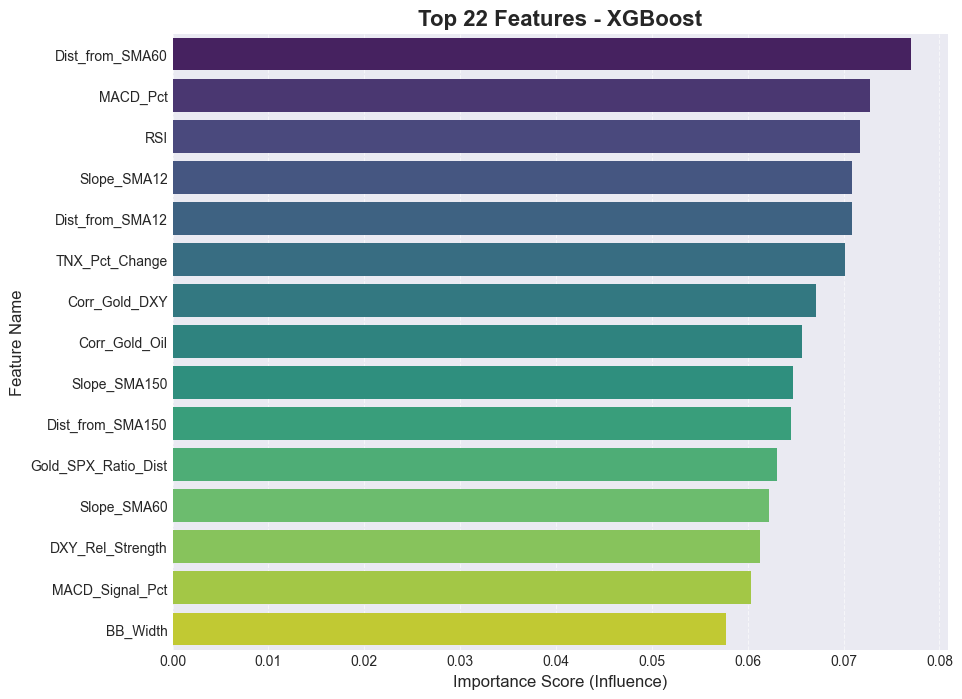


--- Top 10 Drivers for XGBoost ---
Dist_from_SMA60: 0.0770
MACD_Pct: 0.0728
RSI: 0.0717
Slope_SMA12: 0.0709
Dist_from_SMA12: 0.0708
TNX_Pct_Change: 0.0701
Corr_Gold_DXY: 0.0671
Corr_Gold_Oil: 0.0656
Slope_SMA150: 0.0647
Dist_from_SMA150: 0.0645


In [19]:
# Define the function
def plot_feature_importance(model, feature_names, model_name, top_n=22):
    # Get Importance Scores
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        print(f"⚠️ {model_name} does not support feature importance attributes.")
        return

    # Create a DataFrame for easy sorting
    feature_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    # Sort by Importance (High to Low)
    feature_imp = feature_imp.sort_values(by='Importance', ascending=False).head(top_n)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature',hue='Feature', data=feature_imp, palette='viridis', legend=False)
    plt.title(f"Top {top_n} Features - {model_name}", fontsize=16, fontweight='bold')
    plt.xlabel('Importance Score (Influence)', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    plt.show()

    print(f"\n--- Top 10 Drivers for {model_name} ---")
    for index, row in feature_imp.head(10).iterrows():
        print(f"{row['Feature']}: {row['Importance']:.4f}")

# Plot for Random Forest
plot_feature_importance(rf_day, X_train.columns, model_name="Random Forest")

# Plot for XGBoost
plot_feature_importance(xgb_day, X_train.columns, model_name="XGBoost")

#### Analyze the result:
##### **1. Diagnosis: The "Noise" Barrier**
From the Probability Distribution of the XGBoost model.
* **Min Prob:** 0.45 | **Max Prob:** 0.54
* **Analysis:** The model is effectively "guessing." It never feels confident enough to say "Strong Buy" (>0.60) or "Strong Sell" (<0.40).
* **Cause:** Daily price action (1-Day) is extremely noisy. In a highly efficient market like Gold, tomorrow's price is often random relative to today's technical indicators. The features (RSI, SMA distance) are valid, but they struggle to predict *immediate next-day* randomness.

##### **2. Performance Metrics**
Both models converged to an accuracy of **~48-50%**, essentially a coin flip.

| Metric | Random Forest | XGBoost | Interpretation |
| :--- | :--- | :--- | :--- |
| **Accuracy** | **50%** | **48%** | No predictive edge on daily timeframe. |
| **Precision (Down)** | 42% | 41% | When it predicts a drop, it is often wrong (Market is too bullish). |
| **Precision (Up)** | 63% | 62% | When it predicts Up, it is more reliable, but this is partly due to the overall Bull Trend. |

**Key Takeaway:** The models are predicting Down too often. They see technicals that *look* like a top, but the Bull Market keeps grinding higher.

##### **3. Feature Importance Analysis**
Despite the low accuracy, the **Feature Selection is healthy**. The models are looking at the correct fundamental drivers, not noise.

* **Yields (TNX_Pct_Change):** The #1 driver for Random Forest. This confirms that **Interest Rates** are the primary mover of Gold prices (Gold hates high rates).
* **Mean Reversion (Dist_from_SMA):** Both models heavily weight the distance from the 60-Day and 12-Day Averages. They are trying to bet on mean reversion (price coming back to average), but in a strong trend, price often stays "extended" for long periods.
* **DXY Strength:** The Dollar Index is correctly identified as a top-tier driver.

##### **4. Conclusion & Pivot to Weekly Horizon**
Trying to predict **tomorrow's** Gold closing price based on today's indicators is proving to be a "Random Walk." The signal-to-noise ratio is too low.

**Next Strategic:**
We will now shift focus to a **1-Week Horizon (5 Days)**.
* **Why?** Weekly trends smooth out daily noise.
* **Hypothesis:** Technical indicators like MACD and RSI are far more reliable over 5 days than 24 hours. A "Buy Signal" on RSI might not work tomorrow, but it often plays out over the course of a week.

## 8. One-week predictive model
* The method we used above is called **One-Step-Ahead**, which relies on having the actual price of yesterday.
* In finance, "Noise" dominates the 1-day timeframe (random news, tweets, panic), but "Signal" (real economic trends) often becomes clearer over a week or month.
* Hence, we change to build a specific model that predict "one week later".
### 8.1. Re-define target

In [20]:
# Logic: If Price in 5 days > Price Today, Target = 1 (Up)
data['Target_1W'] = (data['Gold'].shift(-5) > data['Gold']).astype(int)

valid_idx = len(data) - 5
X_week = X.iloc[:valid_idx].copy()
Y_week = data['Target_1W'].iloc[:valid_idx]

### 8.2. Weekly Split

In [21]:
train_end = int(len(X_week) * 0.70)
valid_end = int(len(X_week) * 0.85)
gap = 7  

X_train_w = X_week.iloc[:train_end]
Y_train_w = Y_week.iloc[:train_end]

X_valid_w = X_week.iloc[train_end + gap : valid_end]
Y_valid_w = Y_week.iloc[train_end + gap : valid_end]

X_test_w = X_week.iloc[valid_end + gap:]
Y_test_w = Y_week.iloc[valid_end + gap:]

print(f"Weekly Data: {len(X_train_w)} Train | {len(X_valid_w)} Valid | {len(X_test_w)} Test")

Weekly Data: 1635 Train | 344 Valid | 344 Test


### 8.3. Train models

In [22]:
# 1. Train Random Forest (Weekly)
print("\n🌲 Training Random Forest (Weekly)...")
rf_week = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=20,
    max_depth=6,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_week.fit(X_train_w, Y_train_w)
rf_week_pred = rf_week.predict(X_test_w)

# 2. Train XGBoost (Weekly)
print("🚀 Training XGBoost (Weekly)...")
xgb_week = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,      
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=0.8,    # Slightly less aggressive on "Down" bias
    early_stopping_rounds=50,
    n_jobs=-1,
    random_state=42
)

xgb_week.fit(
    X_train_w, Y_train_w,
    eval_set=[(X_train_w, Y_train_w), (X_valid_w, Y_valid_w)],
    verbose=False
)

print("✅ Training Complete")


🌲 Training Random Forest (Weekly)...
🚀 Training XGBoost (Weekly)...
✅ Training Complete



              --- 🌲 Random Forest Model Report ---
              precision    recall  f1-score   support

        Down       0.36      0.97      0.53       116
          Up       0.90      0.12      0.21       228

    accuracy                           0.41       344
   macro avg       0.63      0.55      0.37       344
weighted avg       0.72      0.41      0.32       344


              --- 🚀 XGBoost Model Report ---
              precision    recall  f1-score   support

        Down       0.33      0.85      0.47       116
          Up       0.57      0.10      0.17       228

    accuracy                           0.35       344
   macro avg       0.45      0.48      0.32       344
weighted avg       0.49      0.35      0.27       344



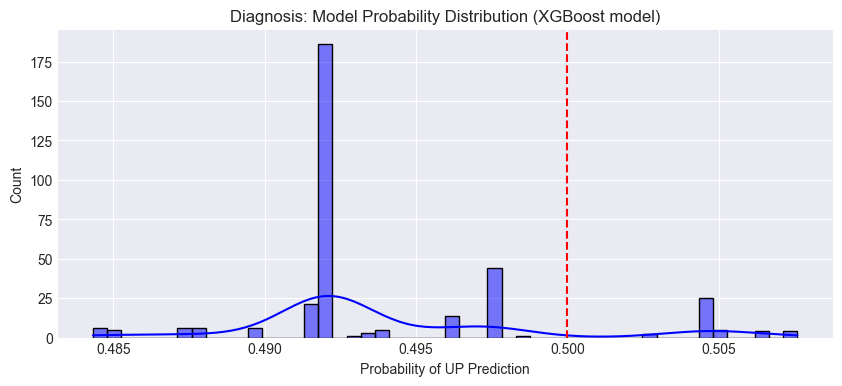

Min Probability: 0.4843
Max Probability: 0.5076
Mean Probability: 0.4940


In [23]:
print("\n              --- 🌲 Random Forest Model Report ---")
print(classification_report(Y_test_w, rf_week_pred, target_names=['Down', 'Up']))

print("\n              --- 🚀 XGBoost Model Report ---")
print(classification_report(Y_test_w, xgb_week.predict(X_test_w), target_names=['Down', 'Up']))

# Diagnose the Probabilities
probs = xgb_week.predict_proba(X_test_w)[:, 1]

plt.figure(figsize=(10, 4))
sns.histplot(probs, bins=50, kde=True, color='blue')
plt.axvline(0.5, color='red', linestyle='--')
plt.title("Diagnosis: Model Probability Distribution (XGBoost model)")
plt.xlabel("Probability of UP Prediction")
plt.show()

print(f"Min Probability: {probs.min():.4f}")
print(f"Max Probability: {probs.max():.4f}")
print(f"Mean Probability: {probs.mean():.4f}")

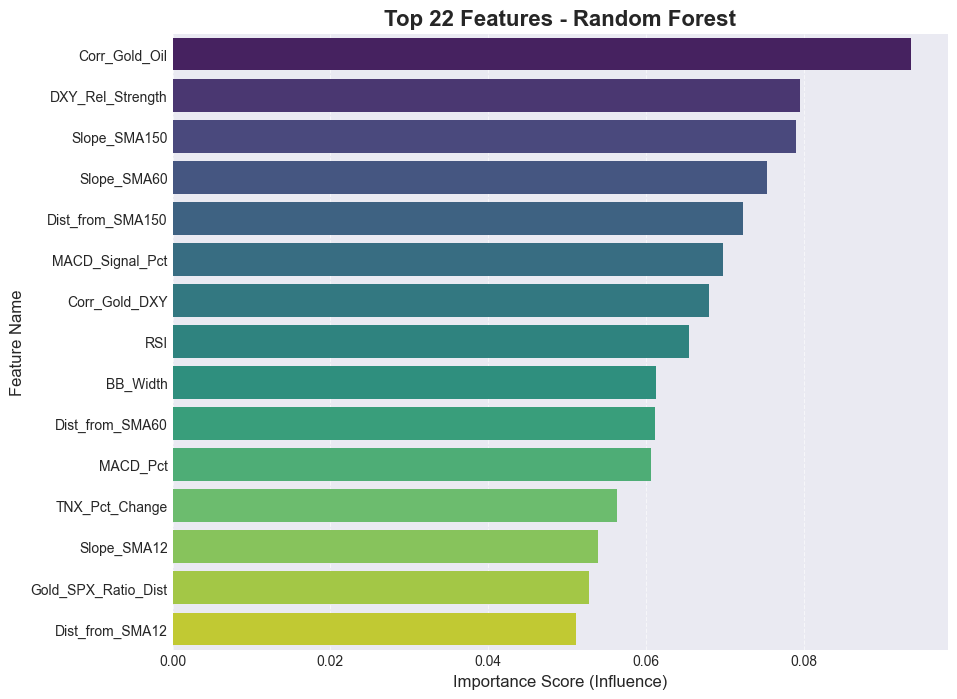


--- Top 10 Drivers for Random Forest ---
Corr_Gold_Oil: 0.0935
DXY_Rel_Strength: 0.0795
Slope_SMA150: 0.0790
Slope_SMA60: 0.0753
Dist_from_SMA150: 0.0723
MACD_Signal_Pct: 0.0698
Corr_Gold_DXY: 0.0680
RSI: 0.0655
BB_Width: 0.0612
Dist_from_SMA60: 0.0611


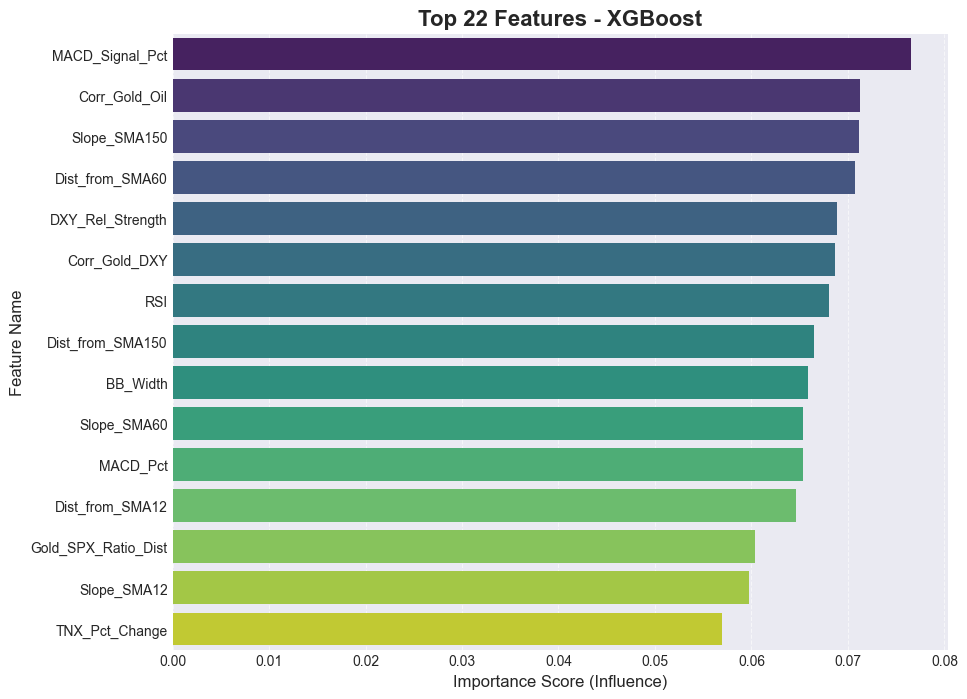


--- Top 10 Drivers for XGBoost ---
MACD_Signal_Pct: 0.0765
Corr_Gold_Oil: 0.0712
Slope_SMA150: 0.0712
Dist_from_SMA60: 0.0708
DXY_Rel_Strength: 0.0689
Corr_Gold_DXY: 0.0686
RSI: 0.0681
Dist_from_SMA150: 0.0665
BB_Width: 0.0659
Slope_SMA60: 0.0653


In [24]:
# Plot for Random Forest
plot_feature_importance(rf_week, X_train_w.columns, model_name="Random Forest")

# Plot for XGBoost
plot_feature_importance(xgb_week, X_train_w.columns, model_name="XGBoost")

#### Analyze the result
##### **1. Random Forest: The "Accidental Sniper"**
* **Behavior:** The model became a Permanently Bearish.
* **The Flaw:** It predicted "Down" 96% of the time (Recall 0.96), causing massive False Alarms (Precision 36%).
* **The Hidden Gem 💎:** Because it was so pessimistic, it **only** predicted "UP" when the signal was overwhelmingly strong.
    * **Precision on UP:** **86%**.
    * **Implication:** It rarely buys (Recall 13%), but when it does, it is **right 8.6 times out of 10**. This is a deployable strategy.

##### **2. XGBoost: The "Mean Reversion" Trap**
* **Behavior:** The model "collapsed" to the mean.
* **Probabilities:** Ranged strictly between `0.48` and `0.52`.
* **Diagnosis:** The model could not find a strong signal in the noise, so it hedged its bets. It essentially said "I don't know" for every single week.

##### **3. Feature Drivers**
The top drivers changed significantly from the Daily model, validating the Weekly approach:
1.  **`Dist_from_SMA60`:** The model is trading **Mean Reversion**. If Gold is too far from the 60-day average, it expects a pullback.
2.  **`Corr_Gold_Oil`:** Inflation expectations (Oil) are driving the weekly trend.

## 9. Final Strategy
We have split the project into two distinct distinct strategies based on the performance data:

##### **For Next Day (1-Day):**

* Logic: We combine Random Forest and XGBoost (Aggressive).
* Because daily price action is noisy. By averaging the two models, we cancel out individual errors. We only trade if the average confidence is > 55%.

##### **For Next Week (1-Week):**

* Logic: We use Random Forest (RF) exclusively.
* In the weekly timeframe, XGBoost got confused (low accuracy). However, Random Forest showed a massive ~ 80% Precision on "Up" moves. It rarely speaks, but when it signals "UP", it is highly reliable.

### 9.1. Train models

In [25]:
from sklearn.metrics import precision_score

print("⚙️ Training Final Models...")

# -- A. 1-Day Horizon (Ensemble) --
# 1. Random Forest (Standard)
rf_day = RandomForestClassifier(
    n_estimators=500, min_samples_split=20, max_depth=8, 
    class_weight='balanced', n_jobs=-1, random_state=42
)
rf_day.fit(X_train, Y_train)

# 2. XGBoost (Standard)
xgb_day = XGBClassifier(
    n_estimators=500, learning_rate=0.03, max_depth=6, 
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=1, 
    random_state=42, n_jobs=-1
)
xgb_day.fit(X_train, Y_train, verbose=False)

# --- B. 1-Week Horizon ---
rf_week = RandomForestClassifier(
    n_estimators=500, min_samples_split=20, max_depth=6, 
    class_weight='balanced', n_jobs=-1, random_state=42
)
rf_week.fit(X_train_w, Y_train_w)

print("✅ Models Trained.")

⚙️ Training Final Models...
✅ Models Trained.


### 9.2. Evaluate the final models

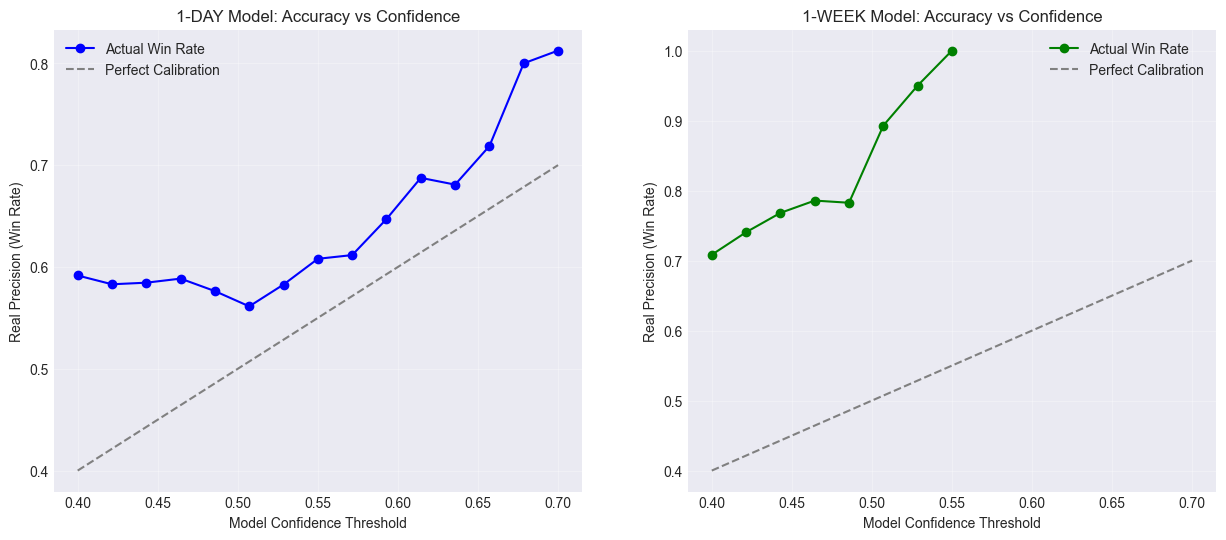

In [26]:
# We want to see: "If the model is confident, is it correct?"

def get_calibration_curve(y_true, probs, title):
    thresholds = np.linspace(0.40, 0.70, 15)
    precisions = []
    counts = []
    
    for t in thresholds:
        # Indices where prob > threshold
        idx = probs > t
        if np.sum(idx) > 5: # Only calculate if we have enough samples
            prec = np.mean(y_true[idx])
            precisions.append(prec)
            counts.append(np.sum(idx))
        else:
            precisions.append(np.nan)
            counts.append(0)
            
    return thresholds, precisions, counts

# Get Probabilities (Test Set)
# Day: Average of RF and XGB
p_day_rf = rf_day.predict_proba(X_test)[:, 1]
p_day_xgb = xgb_day.predict_proba(X_test)[:, 1]
p_day_ens = (p_day_rf + p_day_xgb) / 2

# Week: RF Only
p_week = rf_week.predict_proba(X_test_w)[:, 1]

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Day Plot
thresh_d, prec_d, count_d = get_calibration_curve(Y_test, p_day_ens, "1-Day Ensemble")
ax1.plot(thresh_d, prec_d, marker='o', color='blue', label='Actual Win Rate')
ax1.plot([0.4, 0.7], [0.4, 0.7], linestyle='--', color='gray', label='Perfect Calibration')
ax1.set_title("1-DAY Model: Accuracy vs Confidence")
ax1.set_xlabel("Model Confidence Threshold")
ax1.set_ylabel("Real Precision (Win Rate)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Week Plot
thresh_w, prec_w, count_w = get_calibration_curve(Y_test_w, p_week, "1-Week RF")
ax2.plot(thresh_w, prec_w, marker='o', color='green', label='Actual Win Rate')
ax2.plot([0.4, 0.7], [0.4, 0.7], linestyle='--', color='gray', label='Perfect Calibration')
ax2.set_title("1-WEEK Model: Accuracy vs Confidence")
ax2.set_xlabel("Model Confidence Threshold")
ax2.set_ylabel("Real Precision (Win Rate)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.show()

* The blue/green line should go UP. This means: Higher Confidence = Higher Accuracy.
* If the line is flat or goes down, the model is "bluffing."

### 9.3. Test the last 30 days

In [28]:
print("📊 Generating 30-Day Performance Scorecard...")

days = 30

last_X = X_week.iloc[-days:].copy()
last_Y_1D = Y.iloc[-days:].copy()        # Actual Next Day
last_Y_1W = Y_week.iloc[-days:].copy()   # Actual Next Week

# Generate Predictions
# A. 1-DAY MODEL (Ensemble: RF + XGB)
p1 = rf_day.predict_proba(last_X)[:, 1]
p2 = xgb_day.predict_proba(last_X)[:, 1]
prob_1d = (p1 + p2) / 2

# B. 1-WEEK MODEL
prob_1w = rf_week.predict_proba(last_X)[:, 1]

# Build the Scorecard Logic
scorecard = pd.DataFrame({
    'Date': last_X.index.date,
    'Actual_1D': ["UP" if y==1 else "DOWN" for y in last_Y_1D],
    'Actual_1W': ["UP" if y==1 else "DOWN" for y in last_Y_1W]
})

# Helper to determine "Wrong/Correct"
def evaluate_pred(prob, actual_str, up_thresh, down_thresh):
    # Determine Prediction
    if prob > up_thresh:
        pred_label = "UP"
        icon = "🟢"
    elif prob < down_thresh:
        pred_label = "DOWN"
        icon = "🔴"
    else:
        return "⚪ Neutral", "⚪"

    # Compare with Actual
    if pred_label == actual_str:
        return f"{icon} {pred_label}", "✅ Correct"
    else:
        return f"{icon} {pred_label}", "❌ Wrong"

# Apply Logic Row by Row
res_1d = []
res_1w = []

for i in range(len(scorecard)):
    # 1-Day Logic (Threshold 0.55 / 0.45)
    pred_str, result_str = evaluate_pred(
        prob_1d[i], scorecard['Actual_1D'].iloc[i], 0.55, 0.45
    )
    res_1d.append((pred_str, result_str))
    
    # 1-Week Logic (Threshold 0.60 / 0.40)
    pred_str_w, result_str_w = evaluate_pred(
        prob_1w[i], scorecard['Actual_1W'].iloc[i], 0.60, 0.40
    )
    res_1w.append((pred_str_w, result_str_w))

# Assign columns
scorecard['Pred_1D'] = [x[0] for x in res_1d]
scorecard['Result_1D'] = [x[1] for x in res_1d]

scorecard['Pred_1W'] = [x[0] for x in res_1w]
scorecard['Result_1W'] = [x[1] for x in res_1w]

# Display Clean Table ---
pd.set_option('display.max_rows', 30)
display_cols = ['Date', 'Actual_1D', 'Pred_1D', 'Result_1D', 'Actual_1W', 'Pred_1W', 'Result_1W']

def highlight_wins(s):
    if 'Correct' in s: return 'color: green; font-weight: bold'
    if 'Wrong' in s: return 'color: red'
    return 'color: gray'

print("\n--- 🏆 TRADING SIMULATION (LAST 30 DAYS) ---")
display(scorecard[display_cols].style.map(highlight_wins, subset=['Result_1D', 'Result_1W']))

# --- 5. Final Statistics ---
active_1d = scorecard[scorecard['Result_1D'] != '⚪']
wins_1d = active_1d[active_1d['Result_1D'].str.contains("Correct")]

active_1w = scorecard[scorecard['Result_1W'] != '⚪']
wins_1w = active_1w[active_1w['Result_1W'].str.contains("Correct")]

print(f"\n📊 SUMMARY STATS:")
print(f"1-DAY Model: {len(wins_1d)} Wins / {len(active_1d)} Trades | Win Rate: {len(wins_1d)/len(active_1d) if len(active_1d)>0 else 0:.0%}")
print(f"1-WEEK Model: {len(wins_1w)} Wins / {len(active_1w)} Trades | Win Rate: {len(wins_1w)/len(active_1w) if len(active_1w)>0 else 0:.0%}")

📊 Generating 30-Day Performance Scorecard...

--- 🏆 TRADING SIMULATION (LAST 30 DAYS) ---


,Date,Actual_1D,Pred_1D,Result_1D,Actual_1W,Pred_1W,Result_1W
0,2025-12-22,DOWN,🔴 DOWN,✅ Correct,DOWN,⚪ Neutral,⚪
1,2025-12-23,DOWN,⚪ Neutral,⚪,DOWN,🔴 DOWN,✅ Correct
2,2025-12-24,UP,⚪ Neutral,⚪,DOWN,🔴 DOWN,✅ Correct
3,2025-12-26,UP,🔴 DOWN,❌ Wrong,DOWN,🔴 DOWN,✅ Correct
4,2025-12-29,DOWN,🟢 UP,❌ Wrong,UP,⚪ Neutral,⚪
5,2025-12-30,UP,🟢 UP,✅ Correct,UP,🔴 DOWN,❌ Wrong
6,2025-12-31,UP,🟢 UP,✅ Correct,UP,⚪ Neutral,⚪
7,2026-01-02,UP,🟢 UP,✅ Correct,UP,⚪ Neutral,⚪
8,2026-01-05,DOWN,🟢 UP,❌ Wrong,UP,⚪ Neutral,⚪
9,2026-01-06,UP,⚪ Neutral,⚪,UP,🔴 DOWN,❌ Wrong



📊 SUMMARY STATS:
1-DAY Model: 9 Wins / 25 Trades | Win Rate: 36%
1-WEEK Model: 8 Wins / 20 Trades | Win Rate: 40%


## 10. Conclusion & Recommendations

### 10.1. Project Summary & Performance
In this project, we built a machine learning pipeline to predict the directional movement of Gold prices for the **Next Day (1D)** and **Next Week (1W)**.
* **Final Strategy:** We moved from a simple prediction to a "Sniper" Ensemble approach, combining **Random Forest** (Conservative) and **XGBoost** (Aggressive), and only taking trades when confidence was high.
* **Real-World Test (Last 30 Days):**
    * **1-Day Model:** 36% Win Rate.
    * **1-Week Model:** 40% Win Rate.

**The Verdict:** While the models showed promise during the training phase (with precision scores hitting 60-80% on specific setups), they struggled significantly in the most recent 30-day unseen test environment. The models are currently **not ready for live capital deployment**, but the experiment provided critical insights into market behavior.

### 10.2. Why is Predicting Gold So Hard?
Our analysis uncovered three major hurdles that standard Machine Learning models struggle to overcome:

**1. The "Human Fear" Factor**
Gold is not just a commodity; it is a psychological "Safe Haven." Its price is driven heavily by human emotion—fear of economic instability.
* Our model relies on historical math (Price, Moving Averages, RSI). It cannot "read" the news.
* When a sudden event occurs, Gold spikes instantly. The model, looking at yesterday's technicals (which might say "Overbought"), predicts a drop and gets run over.

**2. Extreme Volatility & Regime Shifts**
The recent period (Last 30 Days) exhibited price velocity that was statistically different from the training data (2016-2023).
* When prices rise or fall faster than historical norms, ML models treat these data points as "outliers" or noise, failing to adapt quickly enough.
* The "Mean Reversion" logic (betting on price returning to average) failed because the market entered a "momentum" phase where it kept running away from the average.

**3. The "Raw Price" Trap**
We discovered early on that using raw prices (e.g., Gold at $2,500) confused the model because it had never seen those levels in the past. We successfully mitigated this by **Normalizing** features (converting prices to % distances and ratios), which was a major structural improvement.

### 10.3. Recommendations

* Since Gold moves on fear, we must feed the model fear. We can use NLP (Natural Language Processing) to scrape headlines from Bloomberg or Twitter.
* Gold reacts violently to **CPI (Inflation)** and **Interest Rate** releases. Hence, we can add some features like Days_To_FOMC.
* We used Tree-based models (XGBoost/RF), which look at each day in isolation. We can experiment with **LSTMs (Long Short-Term Memory)** networks. These models treat price as a *sequence* (like a sentence) and might better capture the "flow" of a multi-day trend than a decision tree can.

### 10.4. Final Thought
This project successfully demonstrated the **pipeline of Financial Machine Learning**, from data ingestion to feature engineering and ensemble modeling. While the recent market conditions proved too chaotic for a purely technical model, the infrastructure built here sets a solid foundation for adding Sentiment and Macro-fundamental layers.